# Series de Tiempo II

In [1]:
import warnings 
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

In [ ]:
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
import statsmodels.api as sm
from numpy.random import normal, seed
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima_model import ARIMA

In [4]:
df_apple = pd.read_csv('./AAPL.csv',index_col='Date',parse_dates=['Date'])
df_tesla = pd.read_csv('./TSLA.csv',index_col='Date',parse_dates=['Date'])

In [9]:
df_apple.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,43.181805,43.613062,42.877969,42.897572,108174400,0.0,0.0
2019-06-03,43.027439,43.595909,41.721424,42.463867,161584400,0.0,0.0
2019-06-04,42.988224,44.063910,42.762796,44.017353,123872000,0.0,0.0
2019-06-05,45.154295,45.328268,44.384898,44.727940,119093600,0.0,0.0
2019-06-06,44.860258,45.445882,44.632378,45.384624,90105200,0.0,0.0
2019-06-07,45.700720,47.026338,45.519399,46.592632,122737600,0.0,0.0
2019-06-10,46.999386,47.871695,46.952829,47.188061,104883600,0.0,0.0
2019-06-11,47.746726,48.026062,47.437989,47.734474,107731600,0.0,0.0
2019-06-12,47.523745,48.018709,47.386528,47.582554,73012800,0.0,0.0


In [10]:
df_tesla.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,37.020000,37.984001,36.820000,37.032001,52033500,0,0.0
2019-06-03,37.102001,37.335999,35.397999,35.793999,65322000,0,0.0
2019-06-04,36.220001,38.796001,35.922001,38.720001,69037500,0,0.0
2019-06-05,39.736000,40.256001,38.369999,39.318001,67554000,0,0.0
2019-06-06,40.888000,42.200001,40.360001,41.189999,101211000,0,0.0
2019-06-07,41.000000,42.167999,40.700001,40.900002,80017500,0,0.0
2019-06-10,42.049999,43.388000,41.801998,42.576000,52925000,0,0.0
2019-06-11,43.827999,44.180000,42.700001,43.419998,58267500,0,0.0
2019-06-12,44.590000,44.675999,41.799999,41.852001,75987500,0,0.0


### Autocorrelación

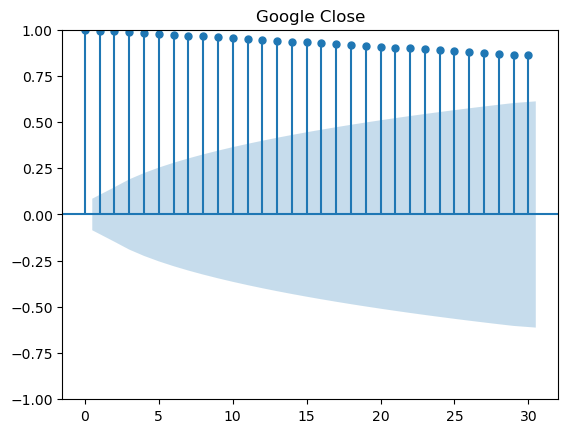

In [11]:
plot_acf(df_tesla['Close'],lags=30,title='Google Close')
plt.show()

### Función parcial de acutocorrelación

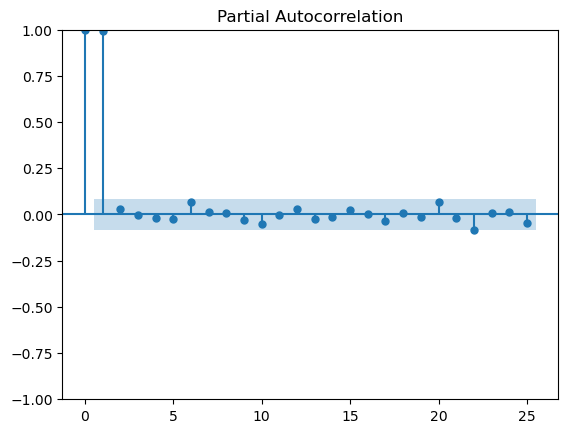

In [12]:
plot_pacf(df_tesla['Close'],lags=25)
plt.show()

### White Noise

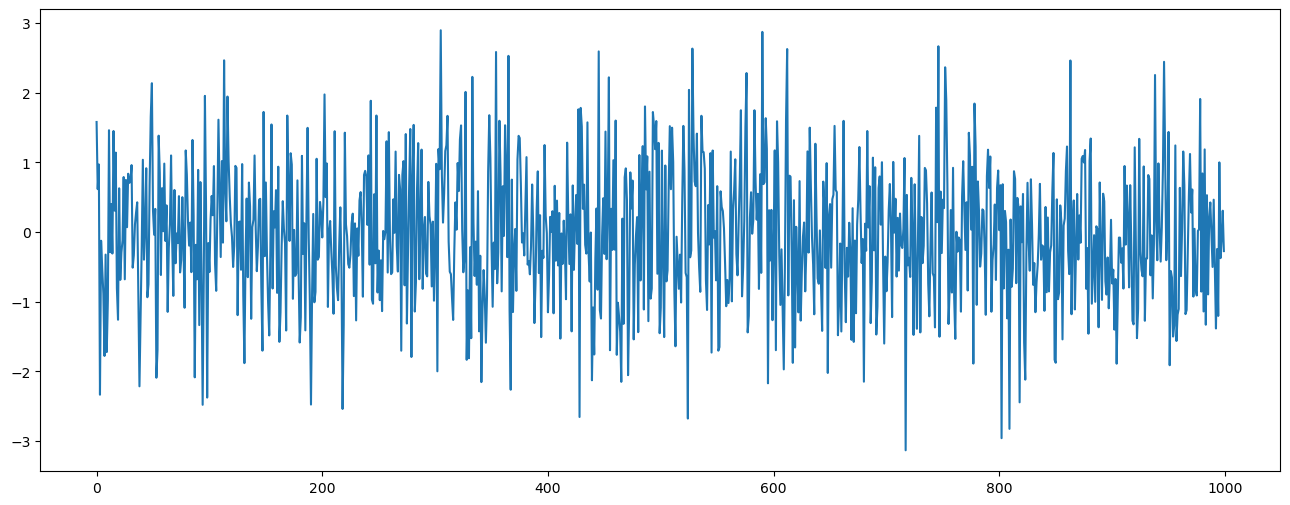

In [13]:
from pylab import rcParams
rcParams['figure.figsize'] = 16,6
white_noise = np.random.normal(loc=0,scale=1,size=1000)
plt.plot(white_noise)

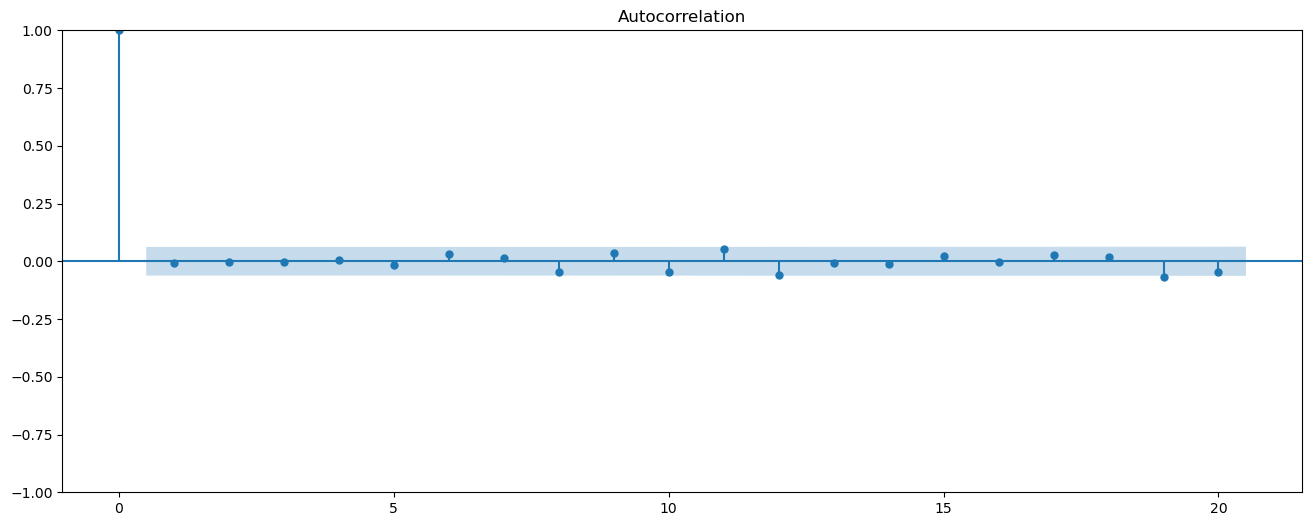

In [14]:
plot_acf(white_noise,lags=20)
plt.show()

In [15]:
from scipy.stats import norm
import pandas as pd

delta = 0.25
dt = 0.1

x = 0.0
xini = 0

n = 10

for k in range(n):
    x = x + norm.rvs(scale=delta**2*dt)
    print(x)

0.0010736108506652917
-0.000547444547340219
-0.005941301622066195
-0.002680817395226181
0.003050884255614887
0.01296430616208694
0.006793638943720766
0.004703517411285735
0.004889947119902587
0.003842286384153751


In [16]:
ntra = 10
n = 20

res = []
dfres = pd.DataFrame().assign(traj=0,nsample=0,sample=0)

In [17]:
dfres

,traj,nsample,sample


In [31]:
# generar las trayectorias en un dataframe (dfres)
import pandas as pd
from scipy.stats import norm
import numpy as np

res = []
datos = []
x = 0

for i in range(ntra + 1):
    x = 0  # reiniciar cada trayectoria

    for k in range(1, n + 1):
        x = x + norm.rvs(scale=delta * np.sqrt(dt))
        res.append(x)

        datos.append({
            'traj': i,
            'nsample': k,
            'sample': x
        })

dfres = pd.DataFrame(datos)

In [27]:
dfres

,traj,nsample,sample
0,0,1,0.069481
1,0,2,-0.031513
2,0,3,-0.141427
3,0,4,-0.190300
4,0,5,-0.160358
...,...,...,...
215,10,16,0.229900
216,10,17,0.288052
217,10,18,0.442026
218,10,19,0.469304


In [28]:
datos = []

for i in range(ntra+1):
    df2 = {'traj':i,'nsample':0,'sample':xini}
    dfres = datos.append(df2)

dfres = pd.DataFrame(datos)

In [29]:
dfres.tail(10)

,traj,nsample,sample
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
5,5,0,0
6,6,0,0
7,7,0,0
8,8,0,0
9,9,0,0
10,10,0,0


<Axes: xlabel='nsample', ylabel='sample'>

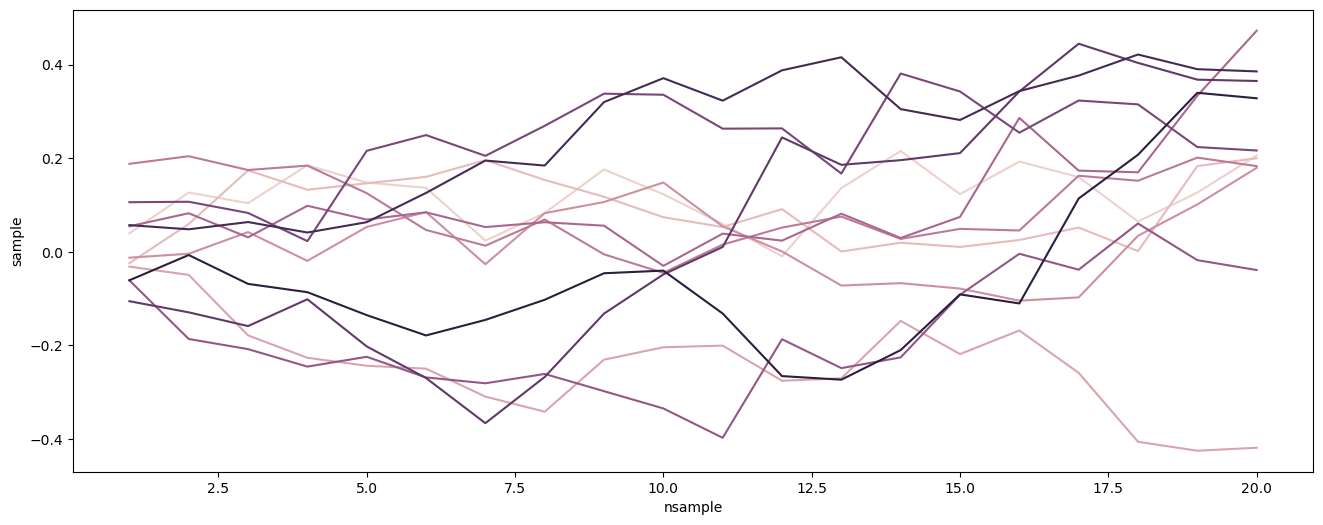

In [32]:
import seaborn as sns
sns.lineplot(data=dfres,x='nsample',y='sample',legend=None,ci=None,hue='traj')

# Exploratory Data Analysis

In [8]:
df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Name
Date,,,,,,,,
2019-05-31,43.181805,43.613062,42.877969,42.897572,108174400,0.0,0.0,APPL
2019-06-03,43.027439,43.595909,41.721424,42.463867,161584400,0.0,0.0,APPL
2019-06-04,42.988224,44.063910,42.762796,44.017353,123872000,0.0,0.0,APPL
2019-06-05,45.154295,45.328268,44.384898,44.727940,119093600,0.0,0.0,APPL
2019-06-06,44.860258,45.445882,44.632378,45.384624,90105200,0.0,0.0,APPL
2019-06-07,45.700720,47.026338,45.519399,46.592632,122737600,0.0,0.0,APPL
2019-06-10,46.999386,47.871695,46.952829,47.188061,104883600,0.0,0.0,APPL
2019-06-11,47.746726,48.026062,47.437989,47.734474,107731600,0.0,0.0,APPL
2019-06-12,47.523745,48.018709,47.386528,47.582554,73012800,0.0,0.0,APPL


In [9]:
df.tail(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Name
Date,,,,,,,,
2021-06-17,129.605821,132.351707,129.456037,131.592834,96721700,0.0,0.0,APPL
2021-06-18,130.514458,131.313248,130.045159,130.264832,108953300,0.0,0.0,APPL
2021-06-21,130.105073,132.211917,129.016708,132.102081,79663300,0.0,0.0,APPL
2021-06-22,131.932333,133.879413,131.423086,133.779556,74783600,0.0,0.0,APPL
2021-06-23,133.569887,134.119068,133.030687,133.499985,60214200,0.0,0.0,APPL
2021-06-24,134.248856,134.438574,132.731126,133.210419,68711000,0.0,0.0,APPL
2021-06-25,133.260356,133.689705,132.611319,132.910873,70783700,0.0,0.0,APPL
2021-06-28,133.210424,135.047667,133.150516,134.578369,62111300,0.0,0.0,APPL
2021-06-29,134.598343,136.285817,134.149019,136.126053,64556100,0.0,0.0,APPL


# Análisis Univariado

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 526 entries, 2019-05-31 to 2021-06-30
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          526 non-null    float64
 1   High          526 non-null    float64
 2   Low           526 non-null    float64
 3   Close         526 non-null    float64
 4   Volume        526 non-null    int64  
 5   Dividends     526 non-null    float64
 6   Stock Splits  526 non-null    float64
 7   Name          526 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 37.0+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,526.0,9.160830e+01,3.077559e+01,4.298822e+01,6.374861e+01,8.686493e+01,1.224732e+02,1.429285e+02
High,526.0,9.272394e+01,3.107684e+01,4.359591e+01,6.491420e+01,8.760879e+01,1.239515e+02,1.444115e+02
Low,526.0,9.049518e+01,3.027810e+01,4.172142e+01,6.337291e+01,8.552844e+01,1.206813e+02,1.407089e+02
Close,526.0,9.165835e+01,3.067098e+01,4.246387e+01,6.427531e+01,8.694675e+01,1.223111e+02,1.424905e+02
Volume,526.0,1.280820e+08,6.144065e+07,4.544800e+07,8.736720e+07,1.112724e+08,1.507170e+08,4.265100e+08
Dividends,526.0,3.075095e-03,2.479227e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e-01
Stock Splits,526.0,7.604563e-03,1.744083e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00


In [12]:
pd.set_option('display.float_format',lambda x:'%.2f' % x)

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,526.00,91.61,30.78,42.99,63.75,86.86,122.47,142.93
High,526.00,92.72,31.08,43.60,64.91,87.61,123.95,144.41
Low,526.00,90.50,30.28,41.72,63.37,85.53,120.68,140.71
Close,526.00,91.66,30.67,42.46,64.28,86.95,122.31,142.49
Volume,526.00,128082046.01,61440648.41,45448000.00,87367200.00,111272350.00,150717025.00,426510000.00
Dividends,526.00,0.00,0.02,0.00,0.00,0.00,0.00,0.22
Stock Splits,526.00,0.01,0.17,0.00,0.00,0.00,0.00,4.00


In [14]:
df[df==0].count()/df.count()*100

Open            0.00
High            0.00
Low             0.00
Close           0.00
Volume          0.00
Dividends      98.48
Stock Splits   99.81
Name            0.00
dtype: float64

In [15]:
df.shape

(526, 8)

# Visualización de series de tiempo

In [16]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Name
Date,,,,,,,,
2019-05-31,43.18,43.61,42.88,42.90,108174400,0.00,0.00,APPL
2019-06-03,43.03,43.60,41.72,42.46,161584400,0.00,0.00,APPL
2019-06-04,42.99,44.06,42.76,44.02,123872000,0.00,0.00,APPL
2019-06-05,45.15,45.33,44.38,44.73,119093600,0.00,0.00,APPL
2019-06-06,44.86,45.45,44.63,45.38,90105200,0.00,0.00,APPL
...,...,...,...,...,...,...,...,...
2021-06-24,134.25,134.44,132.73,133.21,68711000,0.00,0.00,APPL
2021-06-25,133.26,133.69,132.61,132.91,70783700,0.00,0.00,APPL
2021-06-28,133.21,135.05,133.15,134.58,62111300,0.00,0.00,APPL


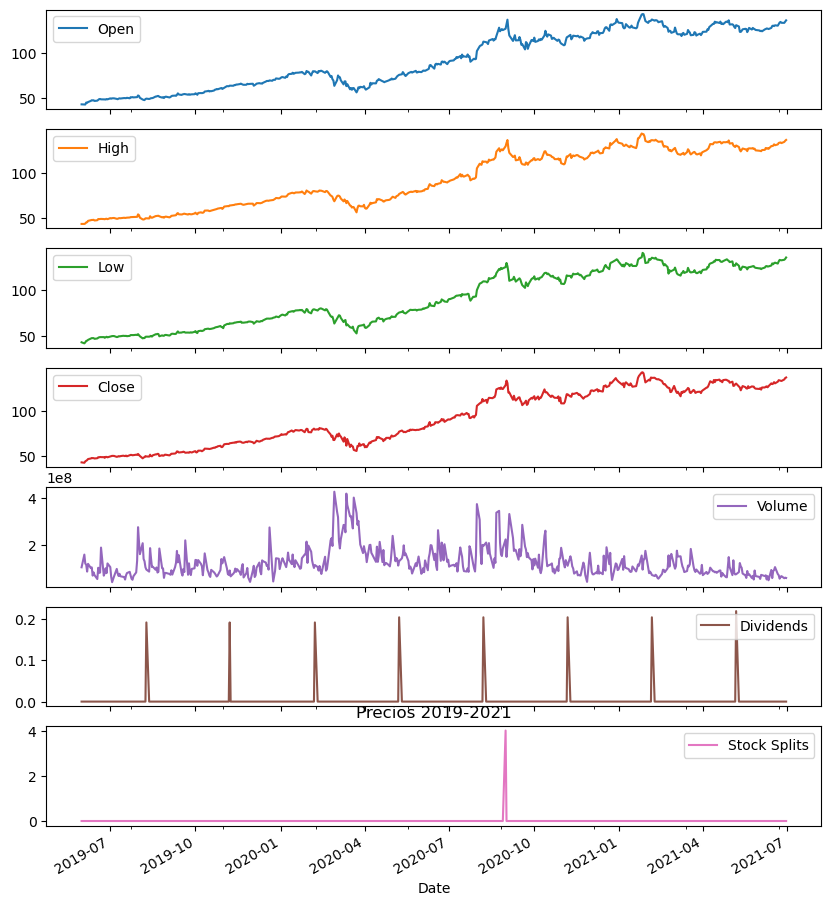

In [17]:
df['2019':'2021'].plot(subplots=True,figsize=(10,12))
plt.title('Precios 2019-2021')
plt.show()

In [18]:
df['Name'].unique()

array(['APPL'], dtype=object)

# Visualización de Lags
 para cambios de tendencia o rupturas de la misma

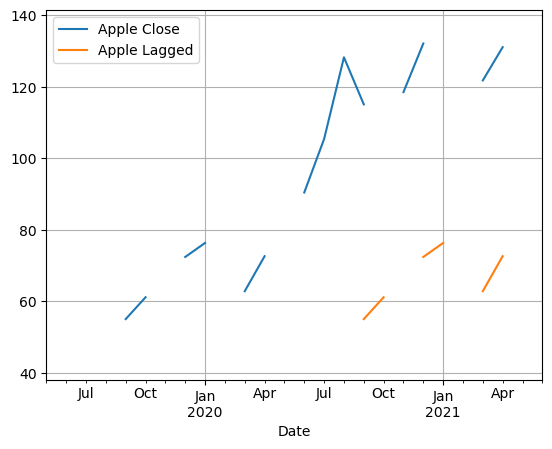

In [19]:
df['Close'].asfreq('M').plot(legend=True)
lag = 12
shifted = df['Close'].asfreq('M').shift(lag).plot(legend=True)
shifted.legend(['Apple Close','Apple Lagged'])
plt.grid()
plt.show()

gráfico de cambio porcentual basado en el close

In [20]:
df['Change'] = df['Close'].div(df['Close'].shift())

In [21]:
pd.set_option('display.float_format',lambda x: '%.4f' % x)
df.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Name,Change
Date,,,,,,,,,
2019-05-31,43.1818,43.6131,42.8780,42.8976,108174400,0.0000,0.0000,APPL,NaN
2019-06-03,43.0274,43.5959,41.7214,42.4639,161584400,0.0000,0.0000,APPL,0.9899
2019-06-04,42.9882,44.0639,42.7628,44.0174,123872000,0.0000,0.0000,APPL,1.0366
2019-06-05,45.1543,45.3283,44.3849,44.7279,119093600,0.0000,0.0000,APPL,1.0161
2019-06-06,44.8603,45.4459,44.6324,45.3846,90105200,0.0000,0.0000,APPL,1.0147
2019-06-07,45.7007,47.0263,45.5194,46.5926,122737600,0.0000,0.0000,APPL,1.0266
2019-06-10,46.9994,47.8717,46.9528,47.1881,104883600,0.0000,0.0000,APPL,1.0128
2019-06-11,47.7467,48.0261,47.4380,47.7345,107731600,0.0000,0.0000,APPL,1.0116
2019-06-12,47.5237,48.0187,47.3865,47.5826,73012800,0.0000,0.0000,APPL,0.9968


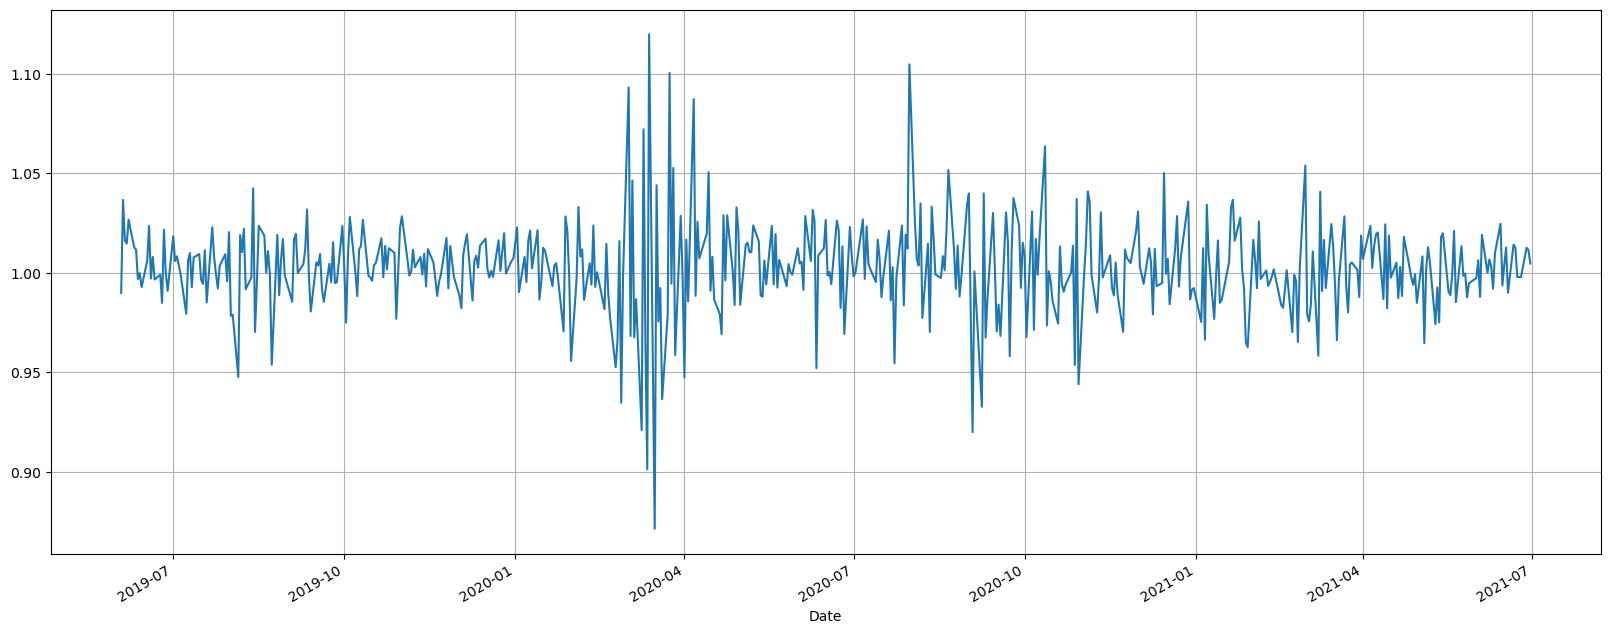

In [22]:
df['Change'].plot(figsize=(20,8)).grid()

In [23]:
# calcular el retorno
df['Return'] = df.Change.sub(1).mul(100)

In [24]:
df.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Name,Change,Return
Date,,,,,,,,,,
2019-05-31,43.1818,43.6131,42.8780,42.8976,108174400,0.0000,0.0000,APPL,NaN,NaN
2019-06-03,43.0274,43.5959,41.7214,42.4639,161584400,0.0000,0.0000,APPL,0.9899,-1.0110
2019-06-04,42.9882,44.0639,42.7628,44.0174,123872000,0.0000,0.0000,APPL,1.0366,3.6584
2019-06-05,45.1543,45.3283,44.3849,44.7279,119093600,0.0000,0.0000,APPL,1.0161,1.6143
2019-06-06,44.8603,45.4459,44.6324,45.3846,90105200,0.0000,0.0000,APPL,1.0147,1.4682
2019-06-07,45.7007,47.0263,45.5194,46.5926,122737600,0.0000,0.0000,APPL,1.0266,2.6617
2019-06-10,46.9994,47.8717,46.9528,47.1881,104883600,0.0000,0.0000,APPL,1.0128,1.2779
2019-06-11,47.7467,48.0261,47.4380,47.7345,107731600,0.0000,0.0000,APPL,1.0116,1.1579
2019-06-12,47.5237,48.0187,47.3865,47.5826,73012800,0.0000,0.0000,APPL,0.9968,-0.3183


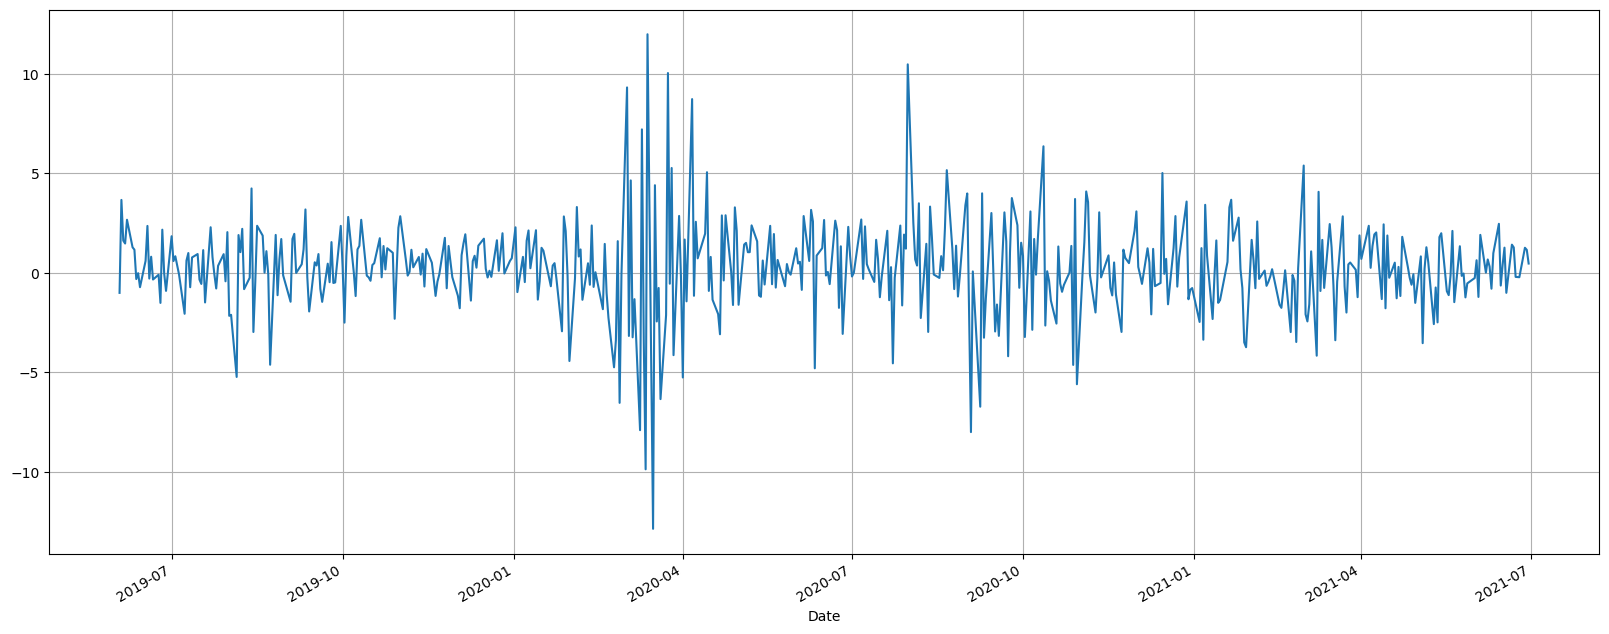

In [25]:
df['Return'].plot(figsize=(20,8)).grid()

# Comparación de dos series

In [26]:
df2 = pd.read_csv('TSLA.csv',index_col='Date',parse_dates=['Date'])

In [27]:
df2.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,37.0200,37.9840,36.8200,37.0320,52033500,0,0.0000
2019-06-03,37.1020,37.3360,35.3980,35.7940,65322000,0,0.0000
2019-06-04,36.2200,38.7960,35.9220,38.7200,69037500,0,0.0000
2019-06-05,39.7360,40.2560,38.3700,39.3180,67554000,0,0.0000
2019-06-06,40.8880,42.2000,40.3600,41.1900,101211000,0,0.0000
2019-06-07,41.0000,42.1680,40.7000,40.9000,80017500,0,0.0000
2019-06-10,42.0500,43.3880,41.8020,42.5760,52925000,0,0.0000
2019-06-11,43.8280,44.1800,42.7000,43.4200,58267500,0,0.0000
2019-06-12,44.5900,44.6760,41.8000,41.8520,75987500,0,0.0000


In [28]:
df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Name,Change,Return
Date,,,,,,,,,,
2019-05-31,43.1818,43.6131,42.8780,42.8976,108174400,0.0000,0.0000,APPL,NaN,NaN
2019-06-03,43.0274,43.5959,41.7214,42.4639,161584400,0.0000,0.0000,APPL,0.9899,-1.0110
2019-06-04,42.9882,44.0639,42.7628,44.0174,123872000,0.0000,0.0000,APPL,1.0366,3.6584
2019-06-05,45.1543,45.3283,44.3849,44.7279,119093600,0.0000,0.0000,APPL,1.0161,1.6143
2019-06-06,44.8603,45.4459,44.6324,45.3846,90105200,0.0000,0.0000,APPL,1.0147,1.4682
2019-06-07,45.7007,47.0263,45.5194,46.5926,122737600,0.0000,0.0000,APPL,1.0266,2.6617
2019-06-10,46.9994,47.8717,46.9528,47.1881,104883600,0.0000,0.0000,APPL,1.0128,1.2779
2019-06-11,47.7467,48.0261,47.4380,47.7345,107731600,0.0000,0.0000,APPL,1.0116,1.1579
2019-06-12,47.5237,48.0187,47.3865,47.5826,73012800,0.0000,0.0000,APPL,0.9968,-0.3183


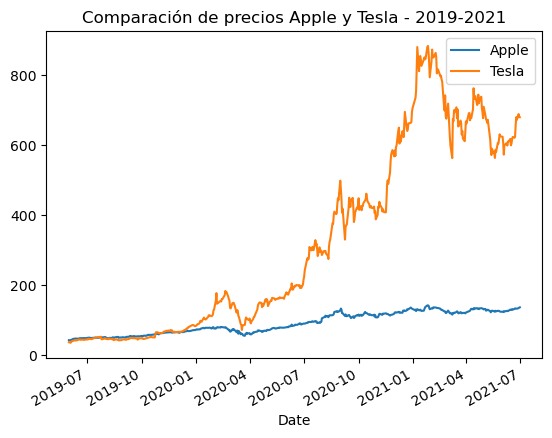

In [29]:
df['Close'].plot()
df2['Close'].plot()
plt.legend(['Apple','Tesla'])
plt.title('Comparación de precios Apple y Tesla - 2019-2021')
plt.show()

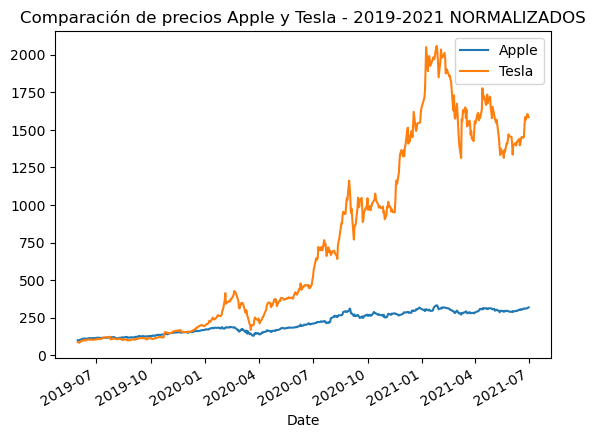

In [30]:
# se normaliza las vistas con base 100 para tener una base de comparación similar 
# la normalización toma como base el primer registro histórico (iloc[0])
# ambos precios empiezan en 100 
normal_apple = df['Close'].div(df['Close'].iloc[0]).mul(100)
normal_google = df2['Close'].div(df['Close'].iloc[0]).mul(100)
normal_apple.plot()
normal_google.plot()
plt.legend(['Apple','Tesla'])
plt.title('Comparación de precios Apple y Tesla - 2019-2021 NORMALIZADOS')
plt.show()

# Visualización de Medias

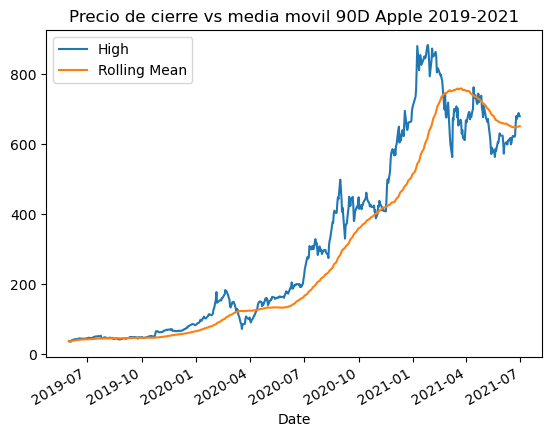

In [31]:
rolling2 = df2['Close'].rolling('90D').mean()
df2['Close'].plot()
rolling2.plot()
plt.title('Precio de cierre vs media movil 90D Apple 2019-2021')
plt.legend(['High','Rolling Mean'])

In [32]:
rolling2

Date
2019-05-31    37.0320
2019-06-03    36.4130
2019-06-04    37.1820
2019-06-05    37.7160
2019-06-06    38.4108
               ...   
2021-06-24   648.7590
2021-06-25   649.1259
2021-06-28   650.5926
2021-06-29   650.7995
2021-06-30   651.0890
Name: Close, Length: 526, dtype: float64

# Visualizaciones financieras: Gráficos OHLC

In [33]:
pip install chart_studio

Note: you may need to restart the kernel to use updated packages.


In [34]:
%matplotlib inline
from pylab import rcParams

from chart_studio import plotly
from chart_studio import grid_objs
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
import statsmodels.api as sm
from numpy.random import normal, seed
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from sklearn.metrics import mean_absolute_error 


In [37]:
df2

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,37.0200,37.9840,36.8200,37.0320,52033500,0,0.0000
2019-06-03,37.1020,37.3360,35.3980,35.7940,65322000,0,0.0000
2019-06-04,36.2200,38.7960,35.9220,38.7200,69037500,0,0.0000
2019-06-05,39.7360,40.2560,38.3700,39.3180,67554000,0,0.0000
2019-06-06,40.8880,42.2000,40.3600,41.1900,101211000,0,0.0000
...,...,...,...,...,...,...,...
2021-06-24,674.9900,697.6200,667.6100,679.8200,45982400,0,0.0000
2021-06-25,689.5800,693.8100,668.7000,671.8700,32496700,0,0.0000
2021-06-28,671.6400,694.7000,670.3200,688.7200,21628200,0,0.0000


In [39]:
df2.index = pd.to_datetime(df2.index)

june = df2.loc['2019-06']

import plotly.graph_objects as go
from plotly.offline import iplot

rango_ohlc = go.Ohlc(
    x=june.index,
    open=june['Open'],
    high=june['High'],
    low=june['Low'],
    close=june['Close']
)

iplot([rango_ohlc])

In [40]:
df2.index = pd.to_datetime(df2.index)

june = df2.loc['2020-06']

import plotly.graph_objects as go
from plotly.offline import iplot

rango_ohlc = go.Ohlc(
    x=june.index,
    open=june['Open'],
    high=june['High'],
    low=june['Low'],
    close=june['Close']
)

iplot([rango_ohlc])

In [41]:
df2.index = pd.to_datetime(df2.index)

june = df2.loc['2020-06']

import plotly.graph_objects as go
from plotly.offline import iplot

rango_ohlc = go.Candlestick(
    x=june.index,
    open=june['Open'],
    high=june['High'],
    low=june['Low'],
    close=june['Close']
)

iplot([rango_ohlc])

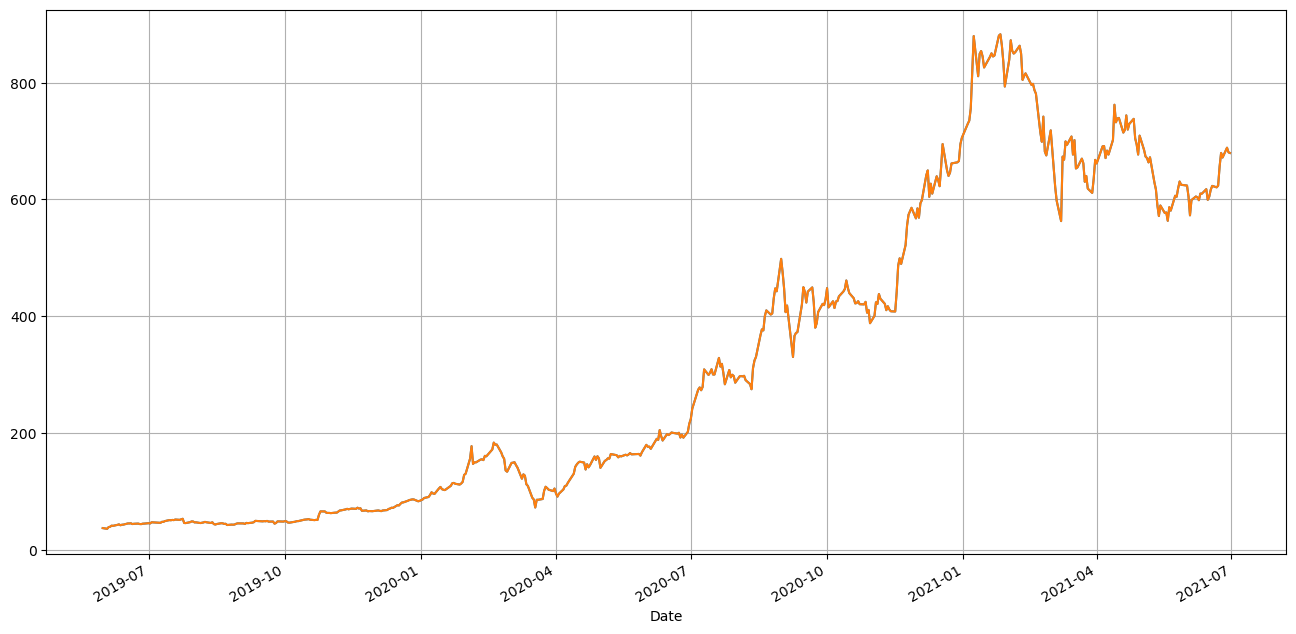

In [43]:
df2['Close'].plot(figsize=(16,8)).grid()
plt.show()

In [52]:
rcParams['figure.figsize'] = 11,9
#decomposed_Tesla_volumen = sm.tsa.seasonal_decompose(df2['Close'],period=360)

#figure = decomposed_Tesla_volumen.plot()

#plt.grid()
#plt.show()

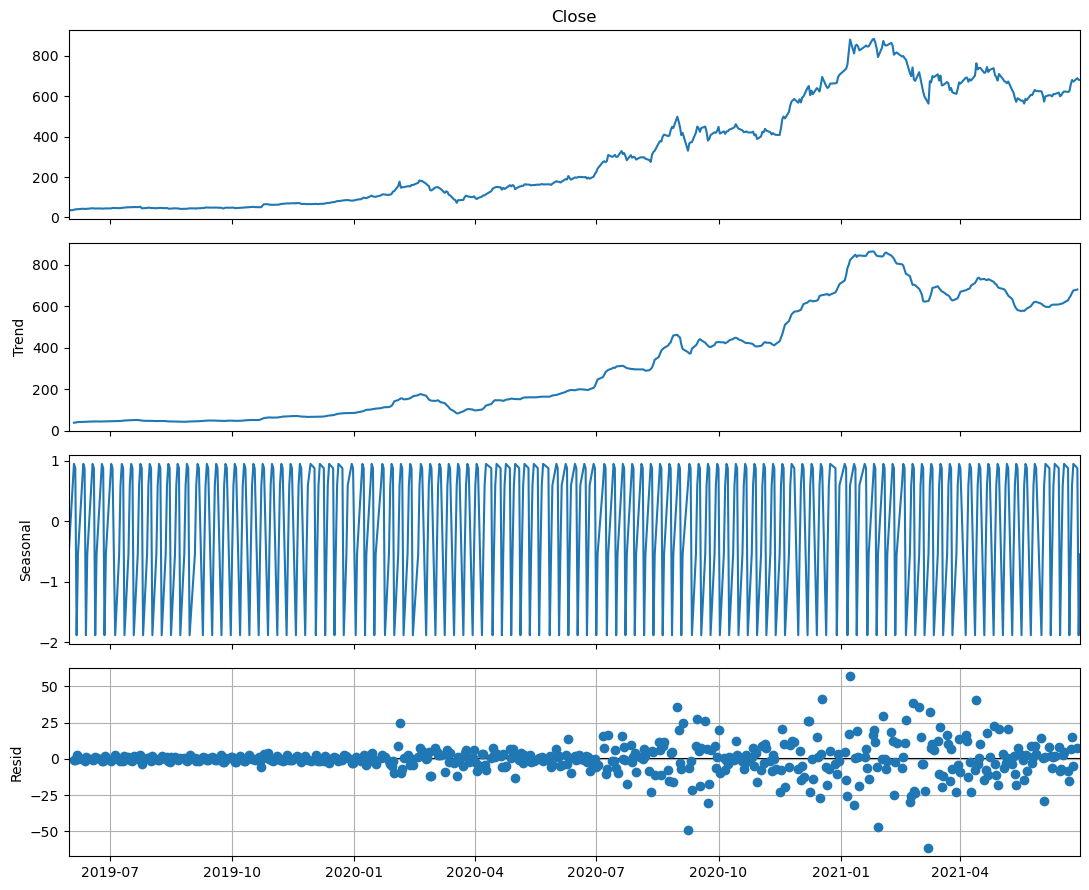

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed = seasonal_decompose(
    df2['Close'],
    model='additive',
    period=5      # weekly seasonality (5 trading days)
)

decomposed.plot()
plt.grid()
plt.show()

In [54]:
df2.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,37.0200,37.9840,36.8200,37.0320,52033500,0,0.0000
2019-06-03,37.1020,37.3360,35.3980,35.7940,65322000,0,0.0000
2019-06-04,36.2200,38.7960,35.9220,38.7200,69037500,0,0.0000
2019-06-05,39.7360,40.2560,38.3700,39.3180,67554000,0,0.0000
2019-06-06,40.8880,42.2000,40.3600,41.1900,101211000,0,0.0000
2019-06-07,41.0000,42.1680,40.7000,40.9000,80017500,0,0.0000
2019-06-10,42.0500,43.3880,41.8020,42.5760,52925000,0,0.0000
2019-06-11,43.8280,44.1800,42.7000,43.4200,58267500,0,0.0000
2019-06-12,44.5900,44.6760,41.8000,41.8520,75987500,0,0.0000


In [58]:
ma_tesla = df2.rolling(window=60)
ma_tesla_mean = ma_tesla.mean()


In [59]:
ma_tesla_mean.tail(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-06-03,662.0180,675.4122,645.8847,660.5220,32699413.3333,0.0000,0.0000
2021-06-04,660.0082,673.4582,644.5870,659.3718,32089933.3333,0.0000,0.0000
2021-06-07,658.2153,671.9165,643.0153,657.7973,31861430.0000,0.0000,0.0000
2021-06-08,657.4322,670.7200,641.8380,656.2950,31735923.3333,0.0000,0.0000
2021-06-09,655.9002,669.0302,640.3978,654.4757,31523406.6667,0.0000,0.0000
2021-06-10,654.2423,667.5080,639.2228,653.3630,31385471.6667,0.0000,0.0000
2021-06-11,653.4650,665.9885,638.3980,651.8310,30982685.0000,0.0000,0.0000
2021-06-14,652.2640,664.9262,637.6843,651.2398,30769338.3333,0.0000,0.0000
2021-06-15,651.7655,664.2522,637.2445,650.3147,30350506.6667,0.0000,0.0000


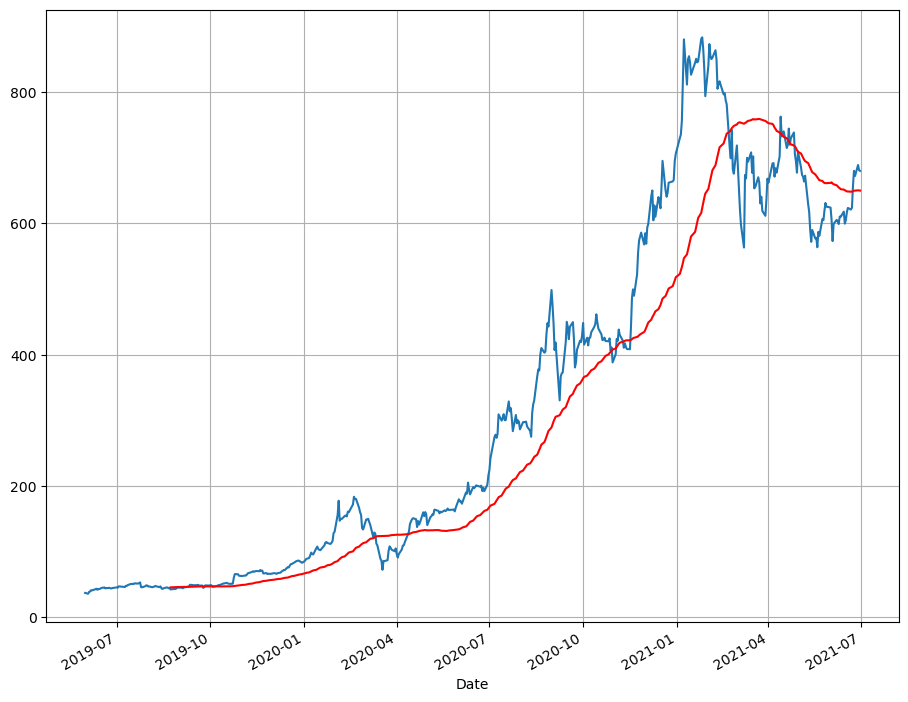

In [60]:
df2['Close'].plot()
ma_tesla_mean['Close'].plot(color='red')
plt.grid()
plt.show()

In [61]:
df2.shape

(526, 7)

In [62]:
train_len = 450
train = df2[0:train_len]
test = df2[train_len:]

In [64]:
y_pred_sma = df2.copy()
ma_window = 30
y_pred_sma['sma_forecast'] = df2['High'].rolling(ma_window).mean()
y_pred_sma['sma_forecast'][train_len] = y_pred_sma['sma_forecast'][train_len-1]

In [66]:
y_pred_sma

,Open,High,Low,Close,Volume,Dividends,Stock Splits,sma_forecast
Date,,,,,,,,
2019-05-31,37.0200,37.9840,36.8200,37.0320,52033500,0,0.0000,NaN
2019-06-03,37.1020,37.3360,35.3980,35.7940,65322000,0,0.0000,NaN
2019-06-04,36.2200,38.7960,35.9220,38.7200,69037500,0,0.0000,NaN
2019-06-05,39.7360,40.2560,38.3700,39.3180,67554000,0,0.0000,NaN
2019-06-06,40.8880,42.2000,40.3600,41.1900,101211000,0,0.0000,NaN
...,...,...,...,...,...,...,...,...
2021-06-24,674.9900,697.6200,667.6100,679.8200,45982400,0,0.0000,617.0047
2021-06-25,689.5800,693.8100,668.7000,671.8700,32496700,0,0.0000,619.9163
2021-06-28,671.6400,694.7000,670.3200,688.7200,21628200,0,0.0000,623.3107


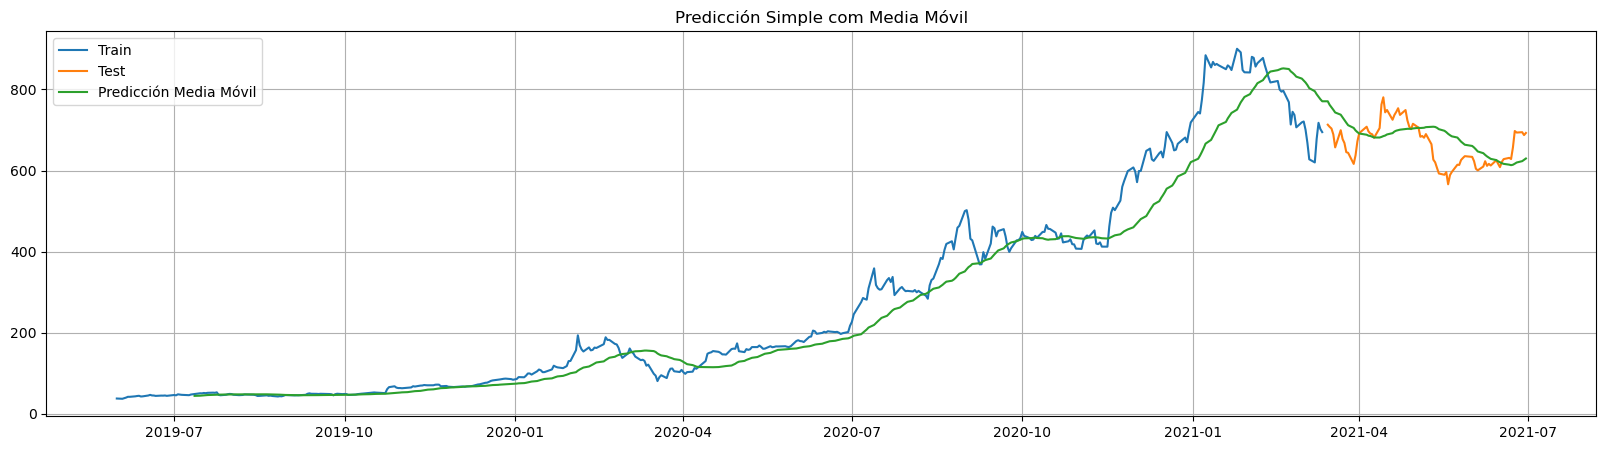

In [65]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['High'],label='Train')
plt.plot(test['High'],label='Test')
plt.plot(y_pred_sma['sma_forecast'],label='Predicción Media Móvil')
plt.legend(loc='best')
plt.title('Predicción Simple com Media Móvil')
plt.show()

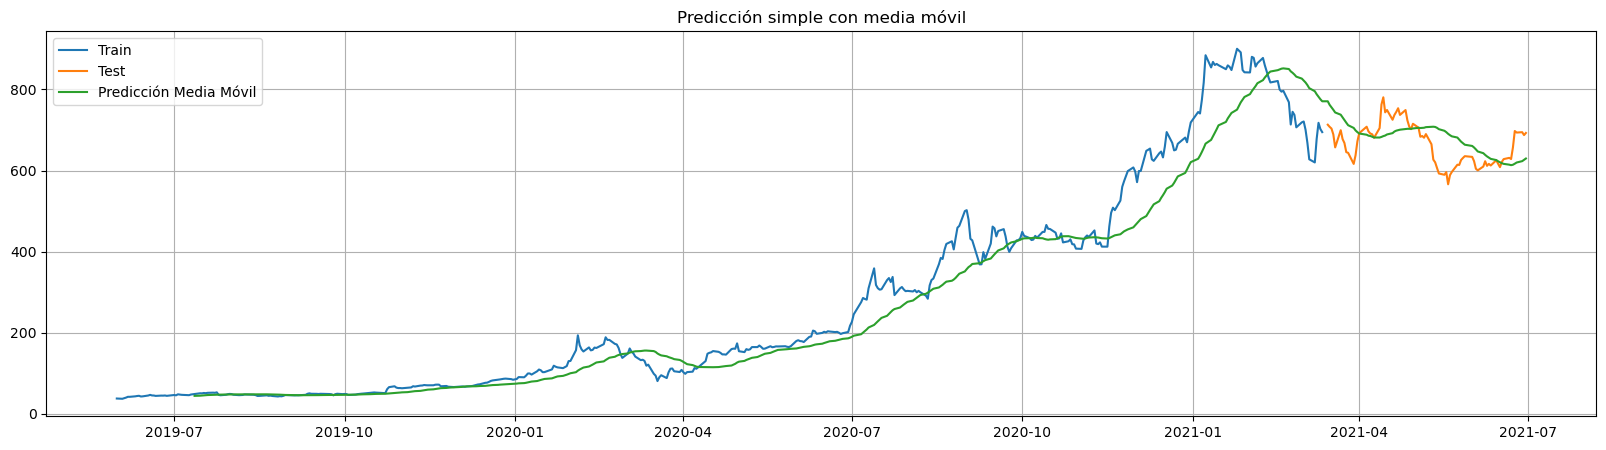

In [68]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['High'],label='Train')
plt.plot(test['High'],label='Test')
plt.plot(y_pred_sma['sma_forecast'],label='Predicción Media Móvil')
plt.legend(loc='best')
plt.title('Predicción simple con media móvil')
plt.show()

In [69]:
from sklearn.metrics import mean_absolute_error
rmse = np.sqrt(mean_absolute_error(test['High'], y_pred_sma['sma_forecast'][train_len:])).round(2)
mape = np.round(np.mean(np.abs(test['High']-y_pred_sma['sma_forecast'][train_len])/test['High'])*100*2)

results = pd.DataFrame({'Method':['Simple moving average forecast'], 'MAPE':[mape],'RMSE':[rmse]})
results = results[['Method','RMSE','MAPE']]
results

,Method,RMSE,MAPE
0,Simple moving average forecast,6.7000,33.0000


In [70]:
y_comparison = pd.DataFrame().assign(forecast=y_pred_sma['sma_forecast'])
y_comparison['observed'] = df2['High']

In [71]:
y_comparison.tail(100)

,forecast,observed
Date,,
2021-02-08,823.0123,877.7700
2021-02-09,829.4693,859.8000
2021-02-10,834.9167,844.8200
2021-02-11,840.2493,829.8800
2021-02-12,844.2737,817.3300
...,...,...
2021-06-24,617.0047,697.6200
2021-06-25,619.9163,693.8100
2021-06-28,623.3107,694.7000
